In [12]:
#importing the necessary libraries
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression


In [3]:
#import the training and testing set
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [4]:
#inspect the training set
train.info()
train.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [5]:
#inspecting the test set
test.info()
test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                270000 non-null  int64  
 1   age               270000 non-null  int64  
 2   gender            270000 non-null  object 
 3   course            270000 non-null  object 
 4   study_hours       270000 non-null  float64
 5   class_attendance  270000 non-null  float64
 6   internet_access   270000 non-null  object 
 7   sleep_hours       270000 non-null  float64
 8   sleep_quality     270000 non-null  object 
 9   study_method      270000 non-null  object 
 10  facility_rating   270000 non-null  object 
 11  exam_difficulty   270000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 24.7+ MB


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [18]:
categorical_columns = train[[
    'gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty'
]]

for col in categorical_columns:
    label_encoder = LabelEncoder()
    train[col] = label_encoder.fit_transform(train[col])

train

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,0,1,7.91,98.8,0,4.9,0,3,1,0,78.300
1,1,18,2,6,4.95,94.8,1,4.7,2,4,2,2,46.700
2,2,20,0,1,4.68,92.6,1,5.8,2,0,0,2,99.000
3,3,19,1,1,2.00,49.5,1,8.3,0,1,0,2,63.900
4,4,23,1,5,7.65,86.9,1,9.6,1,4,0,0,100.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,18,0,2,4.86,70.7,1,4.1,1,2,0,2,69.500
629996,629996,21,0,3,7.08,54.4,1,4.5,0,2,1,2,78.900
629997,629997,24,1,5,0.64,44.2,1,4.3,2,3,1,2,19.599
629998,629998,20,1,0,1.54,75.1,1,8.2,0,1,0,2,59.100


In [19]:
#correlation matrix 
corr_matrix = train.corr()
corr_matrix_exam = (
    corr_matrix['exam_score'].sort_values(ascending=False)
)

print(corr_matrix_exam)

exam_score          1.000000
study_hours         0.762267
class_attendance    0.360954
sleep_hours         0.167410
age                 0.010472
exam_difficulty     0.008337
gender              0.004748
course              0.003874
internet_access     0.000447
id                  0.000372
facility_rating    -0.076605
sleep_quality      -0.124749
study_method       -0.183431
Name: exam_score, dtype: float64


In [21]:
categorical_columns = test[[
    'gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty'
]]

for col in categorical_columns:
    label_encoder = LabelEncoder()
    test[col] = label_encoder.fit_transform(test[col])

test

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,2,3,6.85,65.2,1,5.2,2,1,0,0
1,630001,18,1,6,6.61,45.0,0,9.3,2,0,1,0
2,630002,24,0,2,6.60,98.5,1,6.2,1,1,2,2
3,630003,24,1,6,3.03,66.3,1,5.7,0,2,2,2
4,630004,20,0,2,2.03,42.4,1,9.2,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...
269995,899995,21,2,0,2.55,82.3,1,8.4,0,2,2,1
269996,899996,17,0,0,0.49,46.4,1,8.8,1,2,1,0
269997,899997,22,1,4,6.62,74.7,1,5.5,1,0,0,0
269998,899998,22,2,3,4.08,51.8,1,8.7,2,3,0,2


In [ ]:
X = train[['study_hours', 'class_attendance', 'sleep_hours']]
y = train['exam_score']
model = LinearRegression()
model.fit(X,y)
model.score(X, y)

y_pred = test[['study_hours', 'class_attendance', 'sleep_hours']]
predictions = model.predict(y_pred)
predictions

array([90.93034513, 72.03225754, 71.27355509, ..., 30.11860527,
       50.62682532, 61.43228831], shape=(630000,))

In [46]:
#modelling the residuals
y_train = train['exam_score'].to_numpy()
residuals = y_train - predictions
residuals



array([-12.63034513, -25.33225754,  27.72644491, ..., -10.51960527,
         8.47317468, -24.23228831], shape=(630000,))

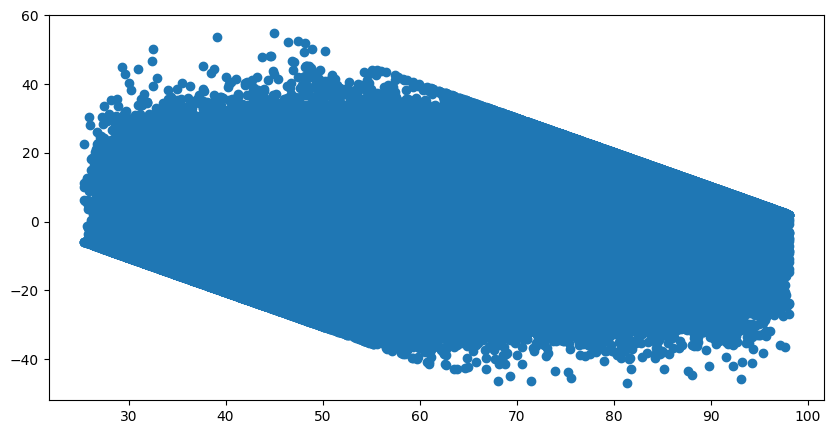

In [48]:
plt.figure(figsize=(10,5))
plt.scatter(predictions, residuals)
plt.show()
